# <b>Loan Default Risk Prediction</b>

## <b>Exploratory Data Analysis (EDA)</b>

### <b>Session 1: Dataset Overview</b>

**Objective:**

The objective of this session is to understand the overall structure of the dataset before performing any preprocessing or feature engineering.

In this session, we will:

- Load the dataset using the Data Ingestion Pipeline
- Inspect the dataset structure
- Understand the dimensions of the dataset
- Identify numerical and categorical features
- Check missing values and duplicate records

#### <b>Step 1: Import Required Libraries</b>

We begin by importing the required libraries for data manipulation and loading the dataset.

Notice that we are **not using `pd.read_csv()` directly**. Instead, we load the data through our production Data Ingestion component.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.components.data_ingestion import DataIngestion

#### <b>Step 2: Load Dataset</b>

The dataset is loaded using the Data Ingestion pipeline.

Using a centralized ingestion component improves maintainability because any future change in the data source only needs to be updated in one place.

In [2]:
ingestion  = DataIngestion()
df = ingestion.load_data()

[2026-07-23 12:24:05,802] INFO - loan_default_project - Loading dataset from: D:\MachineLearningProjects\Loan_Default_Risk_Prediction\data\raw\application_train.csv
[2026-07-23 12:24:16,192] INFO - loan_default_project - Dataset loaded successfully with shape: (307511, 122)


#### <b>Step 3: Display First Five Records</b>

The `head()` function displays the first five rows of the dataset.

This helps us verify:

- Column names
- Data types
- Sample values
- Overall dataset structure

Instead of printing the complete dataset, which contains more than 300,000 records, we inspect only a small sample.

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


##### <b>Observation</b>

- The dataset contains customer demographic and financial information.
- Each row represents one loan application.
- The target variable is **TARGET**.
- The dataset contains both numerical and categorical variables.

#### <b>Step 4: Check Dataset Shape</b>

The shape of the dataset tells us the number of rows and columns available for analysis.

In [4]:
df.shape

(307511, 122)

##### <b>Observation</b>

The dataset contains:

- **307,511 rows**
- **122 columns**

This indicates a relatively large dataset with many features that will require preprocessing before model training.

#### <b>Step 5: Dataset Information</b>

The `info()` function provides:

- Number of rows
- Number of columns
- Non-null values
- Data types
- Memory usage

This is one of the first commands every Data Scientist runs before starting EDA.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


##### <b>Observation</b>

From the dataset information we observe:

- Multiple columns contain missing values.
- Both numerical and categorical features are present.
- Most numerical columns are stored as `float64` or `int64`.
- Several categorical columns are stored as `object`.

#### <b>Step 6: Statistical Summary</b>

The `describe()` function summarizes the numerical features.

It provides:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

In [6]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


##### <b>Observation</b>

The statistical summary helps us identify:

- Features with large ranges
- Possible outliers
- Skewed distributions
- Missing values (through reduced count)

#### <b>Step 7: Missing Value Analysis</b>

Before cleaning the data, we identify which columns contain missing values.

This helps us decide the appropriate imputation strategy during preprocessing.

In [7]:
df.isnull().sum().sort_values(ascending=False).head(10)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
dtype: int64

##### <b>Observation</b>

Several columns contain a high percentage of missing values.

These columns will require careful handling during the feature engineering stage.

At this point, we only identify missing values—we do not remove or impute them.

#### <b>Session 1 Summary</b>

In this session we:

- Successfully loaded the dataset
- Understood the dataset dimensions
- Explored the dataset structure
- Identified numerical and categorical features
- Checked duplicate records
- Identified missing values
- Generated initial business observations

The dataset is now ready for deeper exploratory analysis in the next session.

### <b>Session 2: Target Variable Analysis</b>

**Objective**

The objective of this session is to understand the distribution of the target variable and determine whether the dataset is balanced or imbalanced.

The target variable is `TARGET`, where:

- `0` represents a customer who repaid the loan or did not experience payment difficulty.
- `1` represents a customer who defaulted or experienced payment difficulty.

Target analysis is important because class distribution directly affects model training, evaluation metrics, and sampling strategies.

#### <b>Business Context</b>

The organization wants to identify customers who are likely to default before approving a loan.

In this business problem:

- Correctly identifying a defaulter helps reduce financial loss.
- Missing an actual defaulter can be costly.
- Incorrectly classifying a reliable customer as risky may result in additional verification or rejection of a potentially profitable customer.

Therefore, understanding the number of defaulters and non-defaulters is essential before building the classification model.

#### <b>Step 1: Verify the Target Column</b>

Before analyzing the target variable, we first confirm that the `TARGET` column is present in the dataset.

This prevents the analysis from continuing with an incomplete or incorrect dataset.

In [8]:
target_column = "TARGET"
if target_column not in df.columns:
    raise ValueError(f"Target Column `{target_column}` is missing from the dataset.")
print(f"Target Column '{target_column}' is present.")

Target Column 'TARGET' is present.


#### <b>Step 2: Check Unique Values in the Target Column</b>

A binary classification target should contain two valid classes.

For this project, the expected values are:

- `0`: No default
- `1`: Default

Checking unique values also helps identify unexpected labels or data-quality problems.

In [9]:
target_values = sorted(df[target_column].dropna().unique().tolist())
print(f"Unique target values: {target_values}")

Unique target values: [0, 1]


##### <b>Observation</b>

The `TARGET` column contains two unique values: `0` and `1`.

Therefore, this is a binary classification problem.

No unexpected target labels were identified.

#### <b>Step 3: Check Missing Values in the Target Column</b>

The target column must contain valid labels for model training.

Rows with a missing target cannot be directly used in supervised learning because the expected outcome is unknown.

In [10]:
target_missing_count = df[target_column].isnull().sum()
target_missing_percentage = (
    target_missing_count / len(df)
) * 100

print("Missing target values:", target_missing_count)
print(f"Missing target percentage: {target_missing_percentage:.2f}%")

Missing target values: 0
Missing target percentage: 0.00%


##### <b>Observation</b>

The `TARGET` column does not contain any missing values.

This means every record has a known loan repayment outcome and can potentially be used for supervised model training.

#### <b>Step 4: Calculate the Number of Records in Each Target Class</b>

The `value_counts()` function calculates how many customers belong to each target category.

This helps us compare the number of non-default and default cases.

In [11]:
target_counts = df[target_column].value_counts().sort_index()
print(target_counts)

TARGET
0    282686
1     24825
Name: count, dtype: int64


##### <b>Observation</b>

The dataset contains approximately:

- **282,686 non-default customers**
- **24,825 default customers**

The number of customers who did not default is substantially higher than the number of customers who defaulted.

#### <b>Step 5: Calculate the Percentage Distribution of the Target</b>

Counts show the absolute number of records, while percentages make it easier to understand the relative distribution of each class.

In [12]:
target_percentage = df[target_column].value_counts(normalize=True).sort_index().mul(100).round(2)

print(target_percentage)

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


##### <b>Observation</b>

Approximately:

- **91.93%** of customers belong to the non-default class.
- **8.07%** of customers belong to the default class.

The target classes are not equally distributed. The default class is significantly smaller than the non-default class.

#### <b>Step 6: Create a Target Distribution Summary</b>

A summary table combines target labels, customer counts, and class percentages in a clear and readable format.

In [13]:
target_summary = pd.DataFrame({
    "Target": target_counts.index,
    "Customer_Count": target_counts.values,
    "Percentage": target_percentage.values
})

target_summary['Class_Label'] = target_summary['Target'].map(
    {
        0: "No Default",
        1: "Default"
    }
)

target_summary = target_summary[
    [
        "Target",
        "Class_Label",
        "Customer_Count",
        "Percentage"
    ]
]

print(target_summary)

   Target Class_Label  Customer_Count  Percentage
0       0  No Default          282686       91.93
1       1     Default           24825        8.07


#### <b>Step 7: Visualize the Target Distribution</b>

A bar chart allows us to visually compare the size of the two target classes.

A large difference between the bars indicates class imbalance.

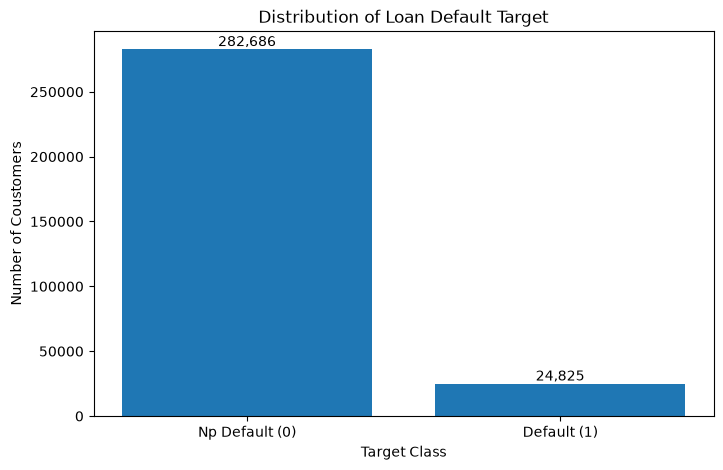

In [14]:
class_labels = ["Np Default (0)", "Default (1)"]
fig,ax = plt.subplots(figsize=(8,5))
bars = ax.bar(class_labels, target_counts.values)
ax.set_title("Distribution of Loan Default Target")
ax.set_xlabel("Target Class")
ax.set_ylabel("Number of Coustomers")

for bar, count in zip(bars, target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.show()

##### <b>Observation</b>

The non-default class is much larger than the default class.

This confirms that the dataset is imbalanced.

A model trained without considering this imbalance may become biased toward predicting the majority class.

#### <b>Step 8: Visualize the Percentage of Each Target Class</b>

The following chart shows the percentage contribution of each class.

This representation makes the degree of class imbalance easier to interpret.

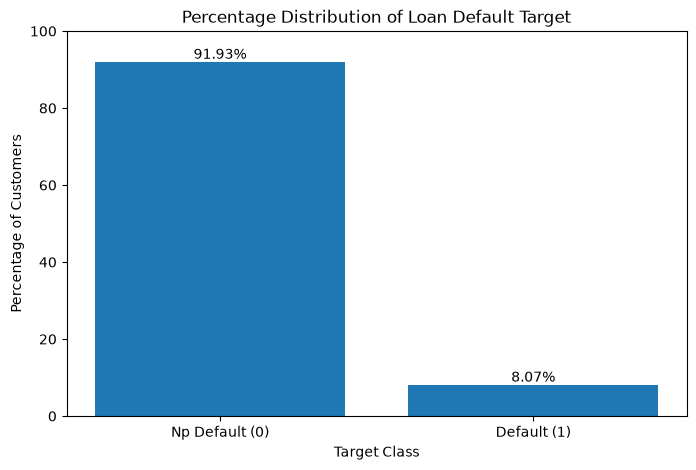

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    class_labels,
    target_percentage.values,
)

ax.set_title("Percentage Distribution of Loan Default Target")
ax.set_xlabel("Target Class")
ax.set_ylabel("Percentage of Customers")
ax.set_ylim(0, 100)

for bar, percentage in zip(bars, target_percentage.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
    )

plt.show()

#### <b>Step 9: Calculate the Class-Imbalance Ratio</b>

The imbalance ratio compares the number of majority-class records with the number of minority-class records.

It helps quantify how much larger the non-default class is than the default class.

In [16]:
non_default_count = target_counts.get(0,0)
default_count = target_counts.get(1,0)

if default_count==0:
    raise ValueError(
        "The default class contains no records. "
        "The imbalance ratio can't be calculated."
    )
imbalance_ratio = non_default_count/default_count
print("Class imbalance ratio: ", f"{imbalance_ratio:.2f}:1")

Class imbalance ratio:  11.39:1


##### <b>Observation</b>

For approximately every one customer who defaults, there are more than eleven customers who do not default.

This is a significant class imbalance and must be considered during:

- Train-test splitting
- Model training
- Model evaluation
- Threshold selection
- Sampling or class-weight decisions

#### <b>Step 10: Why Accuracy Can Be Misleading</b>

Suppose a model predicts every customer as `0`, meaning no customer will default.

Because approximately 91.93% of the records belong to class `0`, this model would achieve approximately 91.93% accuracy.

However, it would fail to identify every actual defaulter.

Therefore, high accuracy does not necessarily mean that the model is useful for the business.

In [17]:
majority_class_accuracy = (
    non_default_count / len(df)
) * 100

print(
    "Accuracy obtained by predicting every customer as non-default:",
    f"{majority_class_accuracy:.2f}%",
)

Accuracy obtained by predicting every customer as non-default: 91.93%


##### <b>Business Interpretation</b>

A model that always predicts `No Default` would achieve high accuracy but would detect none of the actual defaulters.

Such a model would expose the company to financial losses because risky customers could still receive loans.

Therefore, accuracy alone should not be used as the primary model evaluation metric for this project.

#### <b>Step 11: Select Appropriate Evaluation Metrics</b>

Because the dataset is imbalanced, the model should be evaluated using metrics that measure performance on the minority class.

The following metrics will be important:

##### <b>Recall</b>

Recall measures how many actual defaulters are correctly detected.

A high recall means the model misses fewer risky customers.

##### <b>Precision</b>

Precision measures how many customers predicted as defaulters actually defaulted.

A high precision reduces unnecessary rejection or investigation of reliable customers.

##### <b>F1-Score</b>

F1-score balances precision and recall.

It is useful when both false positives and false negatives are important.

##### <b>ROC-AUC</b>

ROC-AUC measures the model's ability to rank default customers above non-default customers across different classification thresholds.

##### <b>PR-AUC</b>

Precision-Recall AUC is especially useful for imbalanced datasets because it focuses more directly on performance for the positive minority class.

##### <b>Metric Priority for This Project</b>

Recall will be an important metric because failing to detect an actual defaulter can cause financial loss.

However, maximizing recall without considering precision may result in too many reliable customers being classified as risky.

Therefore, the final model should balance:

- Recall
- Precision
- F1-score
- ROC-AUC
- Precision-Recall AUC

The final decision threshold should also be selected according to the business cost of false positives and false negatives.

#### <b>Step 12: Business Meaning of Classification Errors</b>

##### <b>False Positive</b>

The model predicts that a customer will default, but the customer would actually repay the loan.

Possible business consequence:

- A reliable customer may face additional verification.
- The loan may be rejected.
- The company may lose a profitable customer.

##### <b>False Negative</b>

The model predicts that a customer will repay the loan, but the customer actually defaults.

Possible business consequence:

- The company may approve a high-risk loan.
- The lender may experience financial loss.
- Recovery and collection costs may increase.

In loan default prediction, false negatives are generally considered especially costly because actual defaulters are missed.

#### <b>Step 13: Modeling Decisions Based on Target Distribution</b>

The target analysis suggests the following modeling decisions:

1. Use a stratified train-test split to preserve the target distribution.
2. Avoid evaluating the model using accuracy alone.
3. Compare recall, precision, F1-score, ROC-AUC, and PR-AUC.
4. Consider class-weighted algorithms.
5. Experiment with sampling techniques only on the training data.
6. Evaluate probability thresholds according to business cost.
7. Compare the model against a majority-class baseline.

##### <b>Important Note About Resampling</b>

Techniques such as SMOTE may be tested later, but they must only be applied to the training dataset.

Applying SMOTE before train-test splitting would create data leakage because synthetic information derived from the complete dataset could influence the test set.

We will compare multiple strategies instead of assuming that SMOTE is automatically the best solution:

- No resampling
- Class weights
- Random undersampling
- Random oversampling
- SMOTE
- Threshold tuning

#### <b>Business Insights</b>

1. Loan defaults represent only a small portion of all applications.
2. Most customers repay their loans, while approximately 8% experience payment difficulty.
3. A model that predicts every customer as non-default can still achieve more than 91% accuracy.
4. Accuracy alone would therefore provide a misleading view of model performance.
5. Missing an actual defaulter may cause direct financial loss.
6. Incorrectly identifying a reliable customer as risky may reduce business opportunities.
7. The final modeling strategy must balance risk reduction with customer approval opportunities.

#### <b>Session 2 Summary</b>

In this session, we:

- Verified the target column
- Confirmed that the problem is binary classification
- Checked missing values in the target
- Calculated target counts and percentages
- Visualized the target distribution
- Measured the class-imbalance ratio
- Demonstrated why accuracy can be misleading
- Identified suitable evaluation metrics
- Interpreted false positives and false negatives
- Defined initial modeling decisions

The dataset is imbalanced, with the default class representing approximately 8% of the observations.

The next session will focus on missing-value analysis across all input features.

### <b>Session 3: Missing-Value Analysis</b>

**Objective**

The objective of this session is to identify, measure, and interpret missing values in the loan application dataset.

Missing-value analysis is important because incomplete information can:

- Reduce the quality of model training
- Cause some machine-learning algorithms to fail
- Introduce bias when handled incorrectly
- Reveal useful business patterns
- Influence feature-selection and imputation decisions

In this session, we will analyze missing values without modifying the original dataset.

#### <b>Business Context</b>

Loan applications may contain missing values for several reasons.

For example:

- A customer may not own a house, car, or property.
- A particular document may not have been submitted.
- External credit-score information may not be available.
- Some fields may not apply to every customer.
- Data may have been lost or incorrectly recorded.

Therefore, a missing value does not always mean that the data is incorrect.

Before deciding how to handle missing values, we must understand their frequency, meaning, and relationship with the business problem.

#### <b>Step 1: Calculate the Total Number of Missing Values</b>

We begin by calculating the total number of missing values across the complete dataset.

This provides a high-level understanding of the overall data-completeness problem.

In [18]:
total_missing_values = int(df.isnull().sum().sum())
print(f"Total Missing values: {total_missing_values:,}")

Total Missing values: 9,152,465


##### <b>Observation</b>

The dataset contains a substantial number of missing values across multiple features.

However, the total count alone is not sufficient because:

- The dataset contains more than 300,000 rows.
- Some columns may contain very few missing values.
- Other columns may contain missing values for most customers.

Therefore, we need to analyze missing values column by column.

#### <b>Step 2: Count Features Containing Missing Values</b>

We calculate how many columns contain at least one missing value.

This helps us understand whether missingness is limited to a few features or spread across a large portion of the dataset.

In [19]:
missing_count_by_column = df.isnull().sum()
columns_with_missing = int((missing_count_by_column>0).sum())
columns_without_missing = int((missing_count_by_column==0).sum())
print(f"Total columns: {df.shape[1]}")
print(f"Columns with missing values: {columns_with_missing}")
print(f"Columns without missing values: {columns_without_missing}")

Total columns: 122
Columns with missing values: 67
Columns without missing values: 55


##### <b>Observation</b>

A large number of features contain at least one missing value.

This indicates that missing-value handling will be an important part of the preprocessing pipeline.

Different features may require different strategies instead of applying one common rule to every column.

#### <b>Step 3: Create a Missing-Value Summary Table</b>

For every feature, we calculate:

- Number of missing values
- Percentage of missing values
- Data type

The percentage is more informative than the raw count because it allows features to be compared consistently.

In [20]:
missing_summary = pd.DataFrame(
    {
        'Column': df.columns,
        'Missing_Count': df.isnull().sum().values,
        'Missing_Percentage' : (df.isnull().mean().values *100),
        'Data_Type': df.dtypes.astype(str).values
    }
)
missing_summary = missing_summary[missing_summary["Missing_Count"]>0].sort_values(by="Missing_Percentage", ascending=False).reset_index(drop=True)

missing_summary['Missing_Percentage'] = missing_summary['Missing_Percentage'].round(2)

missing_summary.head(20)

,Column,Missing_Count,Missing_Percentage,Data_Type
0,COMMONAREA_MEDI,214865,69.87,float64
1,COMMONAREA_MODE,214865,69.87,float64
2,COMMONAREA_AVG,214865,69.87,float64
3,NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
4,NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
5,NONLIVINGAPARTMENTS_AVG,213514,69.43,float64
6,FONDKAPREMONT_MODE,210295,68.39,object
7,LIVINGAPARTMENTS_AVG,210199,68.35,float64
8,LIVINGAPARTMENTS_MEDI,210199,68.35,float64
9,LIVINGAPARTMENTS_MODE,210199,68.35,float64


##### <b>Observation</b>

The summary table shows that some features contain a very high percentage of missing values.

Features with high missing percentages may provide limited information, but they should not be removed automatically.

Before dropping any feature, we should consider:

- Its business meaning
- Its predictive importance
- Whether missingness itself carries information
- Whether the feature can be reliably imputed

#### <b>Step 4: Identify Features with the Highest Missing Percentages</b>

The following table displays the 20 features with the highest missing-value percentages.

These features will require special attention during preprocessing and feature selection.

In [21]:
top_missing_features = missing_summary.head(20)
print(top_missing_features)

                      Column  Missing_Count  Missing_Percentage Data_Type
0            COMMONAREA_MEDI         214865               69.87   float64
1            COMMONAREA_MODE         214865               69.87   float64
2             COMMONAREA_AVG         214865               69.87   float64
3   NONLIVINGAPARTMENTS_MODE         213514               69.43   float64
4   NONLIVINGAPARTMENTS_MEDI         213514               69.43   float64
5    NONLIVINGAPARTMENTS_AVG         213514               69.43   float64
6         FONDKAPREMONT_MODE         210295               68.39    object
7       LIVINGAPARTMENTS_AVG         210199               68.35   float64
8      LIVINGAPARTMENTS_MEDI         210199               68.35   float64
9      LIVINGAPARTMENTS_MODE         210199               68.35   float64
10            FLOORSMIN_MEDI         208642               67.85   float64
11            FLOORSMIN_MODE         208642               67.85   float64
12             FLOORSMIN_AVG         2

#### <b>Step 5: Visualize the Features with the Highest Missing Percentages</b>

A horizontal bar chart makes it easier to compare features with large amounts of missing data.

Only the top 20 features are displayed to keep the chart readable.

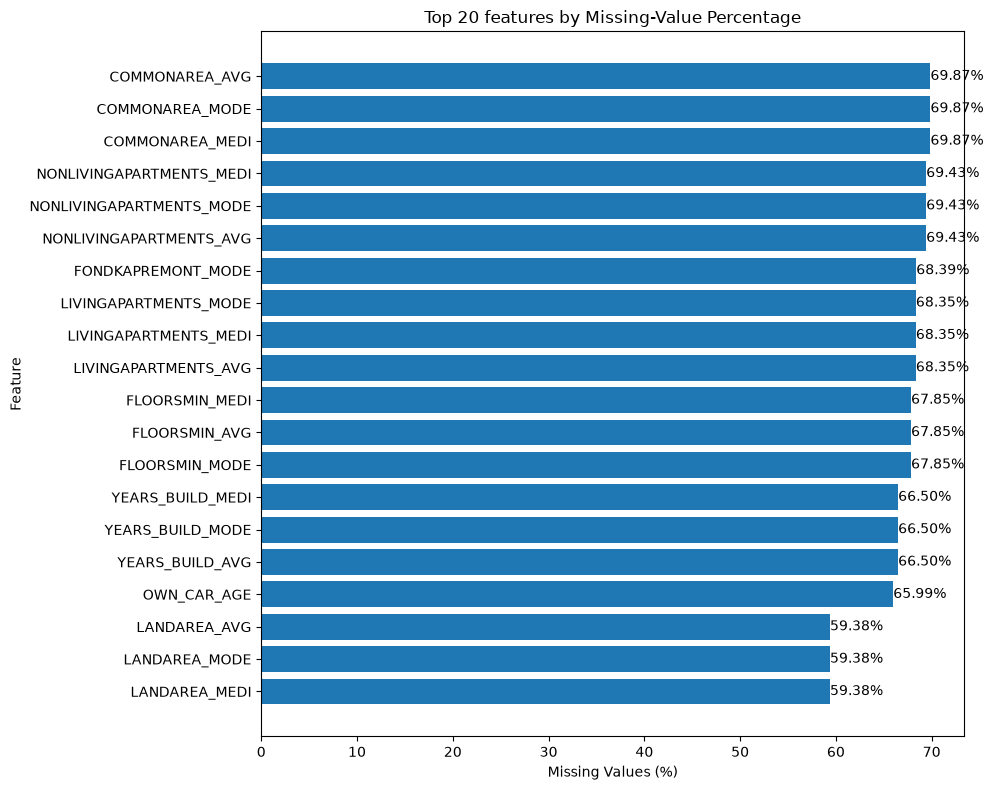

In [22]:
top_missing_for_plot = missing_summary.head(20).sort_values(by="Missing_Percentage", ascending=True)

fig,ax = plt.subplots(figsize=(10,8))
bars = ax.barh(top_missing_for_plot['Column'],
               top_missing_for_plot['Missing_Percentage'])
ax.set_title("Top 20 features by Missing-Value Percentage")
ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Feature")

for bar, percentage in zip(bars, top_missing_for_plot['Missing_Percentage']):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{percentage:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

##### <b>Observation</b>

Several property-related features contain very high missing-value percentages.

One possible explanation is that these features may apply only to customers who own or occupy certain types of property.

The missing values may therefore represent:

- Information not provided
- Information unavailable
- A feature not applicable to the customer

This should be confirmed using the column descriptions and business knowledge before making preprocessing decisions.

#### <b>Step 6: Categorize Features by Missing-Value Severity</b>

To make the analysis easier, we group features into missing-value ranges.

The ranges used are:

- No missing values
- More than 0% and up to 10%
- More than 10% and up to 30%
- More than 30% and up to 50%
- More than 50%

In [23]:
missing_percentage_all = (
    df.isnull().mean() * 100
)

missing_severity = {
    "No Missing Values": int(
        (missing_percentage_all == 0).sum()
    ),
    "0% to 10%": int(
        (
            (missing_percentage_all > 0)
            & (missing_percentage_all <= 10)
        ).sum()
    ),
    "10% to 30%": int(
        (
            (missing_percentage_all > 10)
            & (missing_percentage_all <= 30)
        ).sum()
    ),
    "30% to 50%": int(
        (
            (missing_percentage_all > 30)
            & (missing_percentage_all <= 50)
        ).sum()
    ),
    "Above 50%": int(
        (missing_percentage_all > 50).sum()
    ),
}

missing_severity_df = pd.DataFrame(
    {
        "Missing_Range": missing_severity.keys(),
        "Feature_Count": missing_severity.values(),
    }
)

print(missing_severity_df)

       Missing_Range  Feature_Count
0  No Missing Values             55
1          0% to 10%             10
2         10% to 30%              7
3         30% to 50%              9
4          Above 50%             41


##### <b>Business Interpretation</b>

The missing-value severity groups help us prioritize preprocessing work.

For example:

- Features with low missingness may be imputed using simple methods.
- Features with moderate missingness require more careful analysis.
- Features with very high missingness may be dropped, retained with missing indicators, or imputed using domain-specific rules.

No decision should be made only on the basis of a percentage threshold.

#### <b>Step 7: Check for Completely Empty Features</b>

A completely empty feature contains missing values for every record.

Such a feature provides no usable information and would normally be removed from the modeling dataset.

In [24]:
completely_empty_columns = (
    missing_percentage_all[
        missing_percentage_all == 100
    ]
    .index
    .tolist()
)

print(
    "Number of completely empty columns:",
    len(completely_empty_columns),
)

print(
    "Completely empty columns:",
    completely_empty_columns,
)

Number of completely empty columns: 0
Completely empty columns: []


##### <b>Observation</b>

If no columns are returned, the dataset does not contain any completely empty features.

This means every feature contains at least some available information.

However, features with very high missingness may still require additional review.

#### <b>Step 8: Analyze Missing Values by Feature Type</b>

Numerical and categorical features usually require different missing-value treatments.

Typical strategies include:

##### Numerical Features

- Median imputation
- Mean imputation
- Constant-value imputation
- Model-based imputation

##### Categorical Features

- Most-frequent category
- A separate `Unknown` category
- Business-specific category mapping

We first calculate how many numerical and categorical features contain missing values.

In [25]:
numerical_columns = df.select_dtypes(
    include="number"
).columns

categorical_columns = df.select_dtypes(
    include="object"
).columns

numerical_missing_columns = [
    column
    for column in numerical_columns
    if df[column].isnull().any()
]

categorical_missing_columns = [
    column
    for column in categorical_columns
    if df[column].isnull().any()
]

print(
    "Numerical columns with missing values:",
    len(numerical_missing_columns),
)

print(
    "Categorical columns with missing values:",
    len(categorical_missing_columns),
)

Numerical columns with missing values: 61
Categorical columns with missing values: 6


##### <b>Observation</b>

Both numerical and categorical features contain missing values.

Therefore, the preprocessing pipeline will require separate imputation strategies for each feature type.

A single universal imputation method would not be appropriate for the entire dataset.

#### <b>Step 9: Inspect Missing Values in Categorical Features</b>

For categorical variables, missing values may indicate:

- Unknown information
- Information not submitted
- A category that does not apply
- Data-entry problems

We list categorical features containing missing values and their percentages.

In [26]:
categorical_missing_summary = (
    missing_summary[
        missing_summary["Data_Type"] == "object"
    ]
    .reset_index(drop=True)
)

categorical_missing_summary

,Column,Missing_Count,Missing_Percentage,Data_Type
0,FONDKAPREMONT_MODE,210295,68.39,object
1,WALLSMATERIAL_MODE,156341,50.84,object
2,HOUSETYPE_MODE,154297,50.18,object
3,EMERGENCYSTATE_MODE,145755,47.40,object
4,OCCUPATION_TYPE,96391,31.35,object
5,NAME_TYPE_SUITE,1292,0.42,object


#### <b>Step 10: Inspect Missing Values in Numerical Features</b>

Numerical missing values may require imputation using methods such as the median or a model-based approach.

The median is often preferred over the mean when a feature contains outliers or has a skewed distribution.

In [27]:
numerical_missing_summary = (
    missing_summary[
        missing_summary["Data_Type"] != "object"
    ]
    .reset_index(drop=True)
)

numerical_missing_summary.head(20)

,Column,Missing_Count,Missing_Percentage,Data_Type
0,COMMONAREA_MEDI,214865,69.87,float64
1,COMMONAREA_MODE,214865,69.87,float64
2,COMMONAREA_AVG,214865,69.87,float64
3,NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
4,NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
5,NONLIVINGAPARTMENTS_AVG,213514,69.43,float64
6,LIVINGAPARTMENTS_AVG,210199,68.35,float64
7,LIVINGAPARTMENTS_MEDI,210199,68.35,float64
8,LIVINGAPARTMENTS_MODE,210199,68.35,float64
9,FLOORSMIN_MEDI,208642,67.85,float64


#### <b>Step 11: Check Missingness in Selected Business Features</b>

Some features may be especially important for business interpretation and modeling.

We examine missing values in selected customer, income, credit, employment, and external-score features.

In [28]:
important_features = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "OCCUPATION_TYPE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

available_important_features = [
    column
    for column in important_features
    if column in df.columns
]

important_missing_summary = pd.DataFrame(
    {
        "Column": available_important_features,
        "Missing_Count": [
            int(df[column].isnull().sum())
            for column in available_important_features
        ],
        "Missing_Percentage": [
            round(
                df[column].isnull().mean() * 100,
                2,
            )
            for column in available_important_features
        ],
    }
)

print(important_missing_summary)

              Column  Missing_Count  Missing_Percentage
0             TARGET              0                0.00
1   AMT_INCOME_TOTAL              0                0.00
2         AMT_CREDIT              0                0.00
3        AMT_ANNUITY             12                0.00
4    AMT_GOODS_PRICE            278                0.09
5         DAYS_BIRTH              0                0.00
6      DAYS_EMPLOYED              0                0.00
7    OCCUPATION_TYPE          96391               31.35
8       EXT_SOURCE_1         173378               56.38
9       EXT_SOURCE_2            660                0.21
10      EXT_SOURCE_3          60965               19.83


##### <b>Business Insight</b>

Missingness in important features may have different meanings.

For example:

- Missing occupation information may indicate that employment details were not provided.
- Missing external credit scores may mean that the customer has limited credit-history information.
- Missing annuity or goods-price information may require investigation because these fields relate directly to loan terms.

The business meaning of a missing value should be considered before selecting an imputation strategy.

#### <b>Step 12: Compare Missingness Between Defaulters and Non-Defaulters</b>

Missing information may itself be related to default risk.

For example, customers with limited financial records may have different repayment behavior from customers with complete records.

We compare the average number of missing features per customer across the two target classes.

In [29]:
row_missing_count = df.isnull().sum(axis=1)

missing_by_target = (
    pd.DataFrame(
        {
            "TARGET": df["TARGET"],
            "Missing_Features_Per_Row": row_missing_count,
        }
    )
    .groupby("TARGET")[
        "Missing_Features_Per_Row"
    ]
    .agg(
        [
            "mean",
            "median",
            "min",
            "max",
        ]
    )
    .round(2)
)

print(missing_by_target)

        mean  median  min  max
TARGET                        
0       29.5    34.0    0   61
1       32.8    48.0    0   60


##### <b>Interpretation</b>

This comparison helps determine whether defaulters and non-defaulters differ in the amount of missing information.

If one class has a noticeably higher average number of missing features, missingness itself may contain predictive information.

This suggests that missing-value indicator features could be useful during feature engineering.

#### <b>Step 13: Create a Temporary Missing-Feature Count</b>

For exploratory analysis, we calculate how many features are missing for each customer.

This temporary variable is not added permanently to the original dataset at this stage.

In [30]:
missing_features_per_customer = (
    df.isnull().sum(axis=1)
)

missing_features_per_customer.describe()

count    307511.000000
mean         29.763049
std          20.919345
min           0.000000
25%           5.000000
50%          36.000000
75%          49.000000
max          61.000000
dtype: float64

##### <b>Observation</b>

The summary shows the distribution of incomplete features across customers.

Some customers may have very few missing fields, while others may have many.

During feature engineering, we may create a feature such as:

`TOTAL_MISSING_FEATURES`

This could help the model capture the overall completeness of a customer's application.

#### <b>Step 14: Preliminary Missing-Value Strategy</b>

Based on the analysis, the following strategies may be evaluated later:

##### Low Missing Percentage

- Numerical: median imputation
- Categorical: most-frequent category or `Unknown`

##### Moderate Missing Percentage

- Analyze business relevance
- Add a missing-value indicator
- Apply robust imputation
- Compare model performance with and without the feature

##### High Missing Percentage

- Investigate the business meaning
- Consider dropping the feature
- Retain it if missingness is informative
- Add an explicit missing indicator
- Compare through cross-validation

These are preliminary decisions only. Final handling will be implemented in the preprocessing pipeline.

#### <b>Important: Avoid Data Leakage During Imputation</b>

Imputation values must be learned only from the training dataset.

For example, the median of a numerical feature should be calculated from the training data and then applied to both:

- Training data
- Validation or test data

Calculating imputation values from the complete dataset would expose information from the test data to the training process and create data leakage.

We will prevent this by using a Scikit-learn pipeline during the transformation stage.

#### <b>Business Insights</b>

1. Missing values are distributed across many features rather than being limited to one or two columns.
2. Several property-related features contain high missing percentages.
3. Missingness may represent unavailable, unreported, or non-applicable information.
4. Features with high missingness should not be dropped automatically.
5. Numerical and categorical features require different treatment strategies.
6. Missing information may itself be related to default risk.
7. Missing-value handling must be learned from the training data only to prevent data leakage.

#### <b>Session 3 Summary</b>

In this session, we:

- Calculated the total number of missing values
- Counted features containing missing values
- Created a missing-value summary table
- Identified features with the highest missing percentages
- Grouped features by missing-value severity
- Checked for completely empty features
- Analyzed missing values by data type
- Reviewed missingness in important business features
- Compared missingness across target classes
- Discussed preliminary imputation strategies
- Identified a possible missing-count feature
- Reviewed how to prevent data leakage during imputation

No missing values were removed or imputed during this session.

The next session will focus on numerical-feature analysis.